# Multi-channel image data
Beyond two dimensional images which can be expressed as 2-D matrix, also higher dimensional, multi-channel images are quite common. For example let's import the ```hela-cells.tif``` image: 

In [1]:
from skimage.io import imread
import stackview

In [2]:
image = imread('data/hela-cells-8bit.tif')

[[[ 3  6  1]
  [ 3  7  0]
  [ 3  6  1]
  ...
  [11  8  2]
  [11  7  2]
  [11 11  2]]

 [[ 3  6  1]
  [ 3  8  1]
  [ 3  7  1]
  ...
  [11 10  2]
  [10 10  2]
  [11 11  2]]

 [[ 4  6  1]
  [ 3  6  1]
  [ 4  6  1]
  ...
  [10 10  2]
  [11 10  2]
  [11 10  2]]

 ...

 [[15 14  8]
  [14 14  8]
  [15 14  7]
  ...
  [10 11  5]
  [10 12  4]
  [11 14  5]]

 [[14 16  7]
  [16 15  7]
  [15 16  8]
  ...
  [10 11  4]
  [11 13  4]
  [11 16  5]]

 [[15 18  7]
  [14 17  8]
  [14 17  8]
  ...
  [ 9 12  5]
  [10 13  5]
  [11 15  5]]]
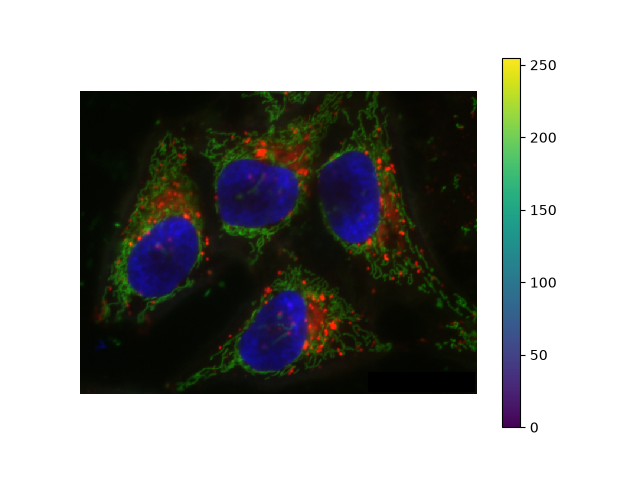
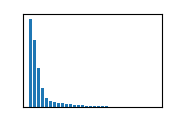

In [3]:
stackview.insight(image)

The image has a 3-dimensional shape:

In [4]:
image.shape

(512, 672, 3)

We see that instead of just pixel rows and columns, we now have an additional number that tells us we have three planes in our data. In this case each image corresponds to a channel but for other data they could be z-planes, time points etc.

## Splitting channels
We can also visualize these three channels independently by splitting them. Furthermore, we can arrange multiple images side-by-side using [matplotlib subplots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html):

[[ 3  3  3 ... 11 11 11]
 [ 3  3  3 ... 11 10 11]
 [ 4  3  4 ... 10 11 11]
 ...
 [15 14 15 ... 10 10 11]
 [14 16 15 ... 10 11 11]
 [15 14 14 ...  9 10 11]]
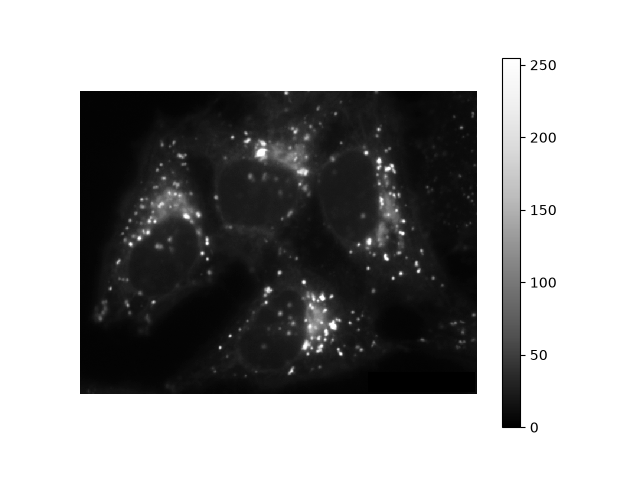
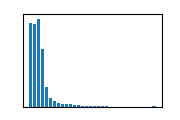

In [5]:
channel1 = image[:,:,0]
channel2 = image[:,:,1]
channel3 = image[:,:,2]

stackview.insight(channel1)

[[ 6  7  6 ...  8  7 11]
 [ 6  8  7 ... 10 10 11]
 [ 6  6  6 ... 10 10 10]
 ...
 [14 14 14 ... 11 12 14]
 [16 15 16 ... 11 13 16]
 [18 17 17 ... 12 13 15]]
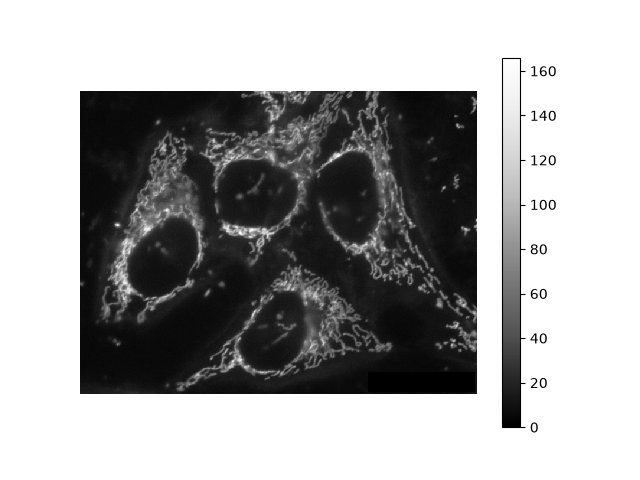
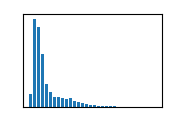

In [6]:
stackview.insight(channel2)

[[1 0 1 ... 2 2 2]
 [1 1 1 ... 2 2 2]
 [1 1 1 ... 2 2 2]
 ...
 [8 8 7 ... 5 4 5]
 [7 7 8 ... 4 4 5]
 [7 8 8 ... 5 5 5]]
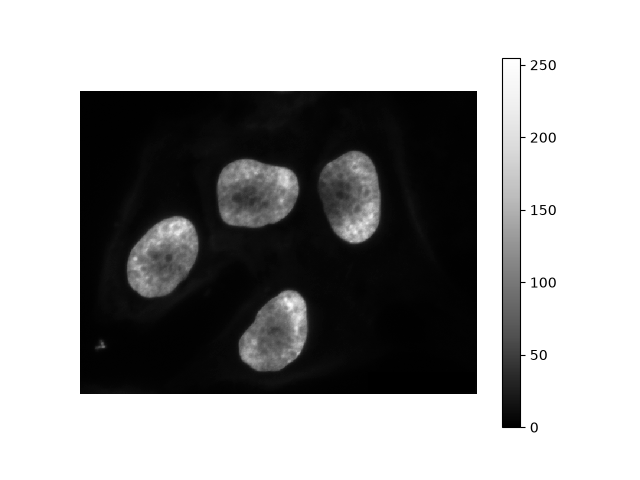
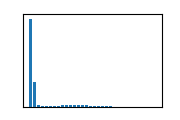

In [7]:
stackview.insight(channel3)

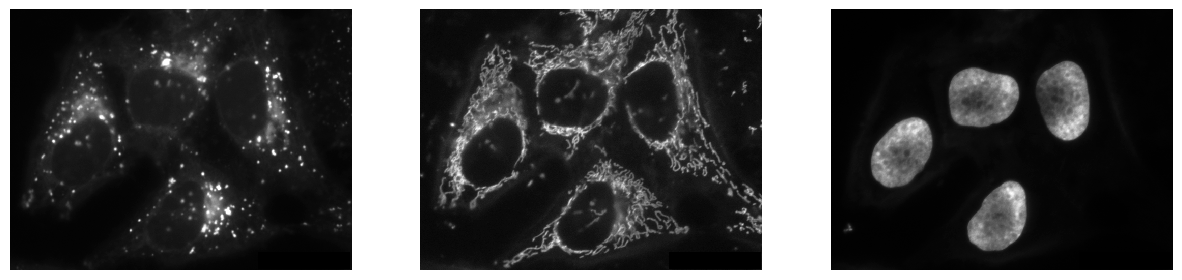

In [8]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(15,15))

stackview.imshow(channel1, plot=axs[0])
stackview.imshow(channel2, plot=axs[1])
stackview.imshow(channel3, plot=axs[2])

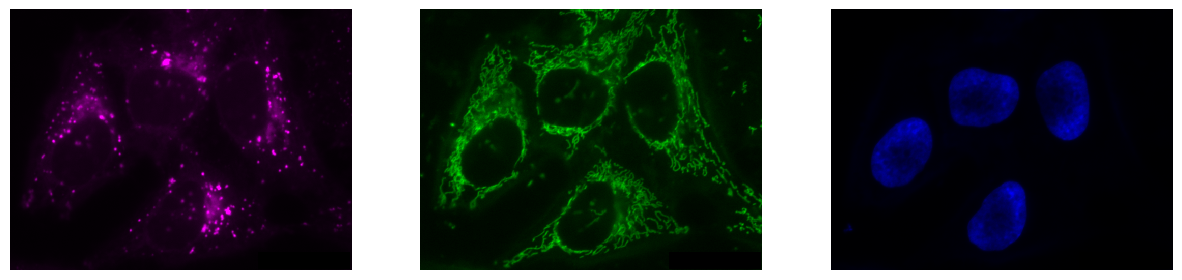

In [9]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(15,15))

stackview.imshow(channel1, plot=axs[0], colormap="pure_magenta")
stackview.imshow(channel2, plot=axs[1], colormap="pure_green")
stackview.imshow(channel3, plot=axs[2], colormap="pure_blue")

In [10]:
stackview.switch(images={"Lysosomes":channel1, 
                         "Mitochondria":channel2, 
                         "Nuclei":channel3}, 
                 toggleable=True,
                 colormap=['pure_magenta', 
                           'pure_green', 
                           'pure_blue'])

## Exercise
Visualize the image with nuclei in cyan, lysosomes in red. Check out the documentation of [Matplotlib's colourmaps](https://matplotlib.org/stable/users/explain/colors/colormaps.html) which can be used in stackview.